In [1]:
import matplotlib.pyplot as plt
import numpy as np

import hea
from hea import data
from hea.models import gam, glm, gmm, lm
from hea.plot import interaction_plot, pairs
from hea.R import AIC, anova
from hea.tidy import col

### 1.1.2

In [2]:
hubble = data("hubble", "gamair")
hubble.head()

Galaxy,y,x
enum,i64,f64
"""NGC0300""",133,2.0
"""NGC0925""",664,9.16
"""NGC1326A""",1794,16.14
"""NGC1365""",1594,17.95
"""NGC1425""",1473,21.88


In [3]:
m_hub = lm("y ~ x - 1", data=hubble)
m_hub.summary()

Formula: y ~ x - 1

Residuals:
    Min      1Q Median     3Q    Max
-736.49 -132.52 -19.00 172.19 557.98

Coefficients:
   Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
x    76.581       3.965     68.38      84.78    19.32  1.03e-15  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 24, p = 1, Residual SE = 258.933 on 23 DF
R-Squared = 0.9419, adjusted R-Squared = 0.9394
F-statistics = 373.0807 on 1 and 23 DF, p-value: 1.031907e-15

Log Likelihood = -166.9015, AIC = 337.8030, BIC = 340.1591

In [4]:
m_hub_no_outliers = lm(
    "y ~ x - 1", data=hubble.filter(np.ravel(np.abs(m_hub.residuals) < 300))
)
m_hub_no_outliers.summary()

Formula: y ~ x - 1

Residuals:
    Min      1Q Median     3Q    Max
-304.25 -141.94 -26.50 138.26 269.78

Coefficients:
   Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
x    77.673       2.970     71.50      83.85    26.15    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 22, p = 1, Residual SE = 180.464 on 21 DF
R-Squared = 0.9702, adjusted R-Squared = 0.9688
F-statistics = 683.8241 on 1 and 21 DF, p-value: 1.659996e-17

Log Likelihood = -145.0066, AIC = 294.0132, BIC = 296.1953

Text(0.5, 0.98, 'm_hub vs. m_hub_no_outliers')

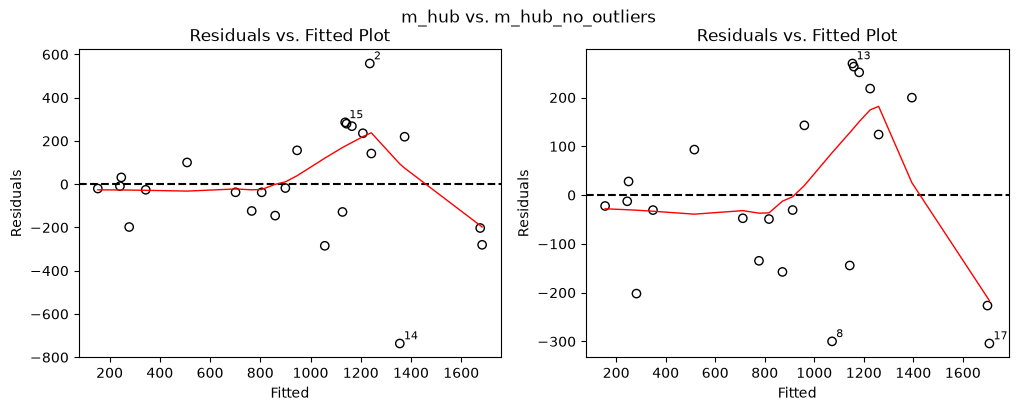

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
m_hub.plot_residuals(ax=ax[0])
m_hub_no_outliers.plot_residuals(ax=ax[1])
fig.suptitle("m_hub vs. m_hub_no_outliers")

### 1.5

In [6]:
sperm = data("sperm.comp1", "gamair")
sperm.head()

subject,time.ipc,prop.partner,count
enum,i64,f64,i64
"""A""",60,0.2,570
"""B""",149,0.98,219
"""D""",70,0.5,485
"""F""",168,0.5,516
"""K""",48,0.2,448


array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

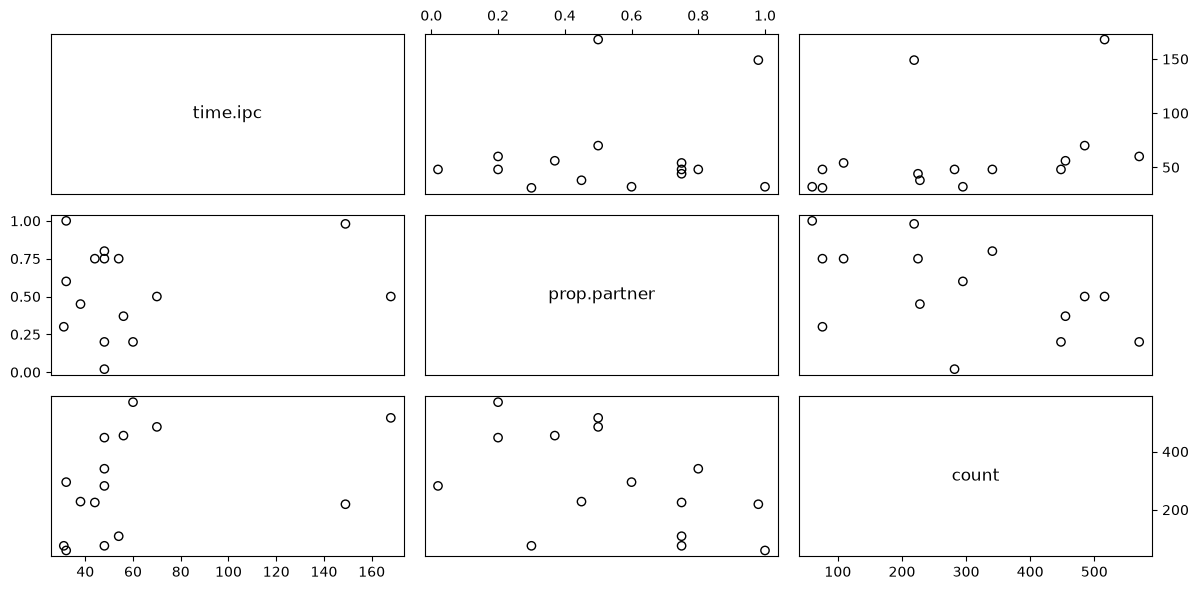

In [7]:
pairs(sperm, figsize=(12, 6))

In [8]:
m1_sc = lm("count ~ time.ipc + prop.partner", data=sperm)
m1_sc.summary()

Formula: count ~ time.ipc + prop.partner

Residuals:
     Min      1Q Median     3Q     Max
-239.740 -96.772  2.171 96.837 163.997

Coefficients:
               Estimate  Std. Error    CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)    357.4184     88.0822   165.50390  549.33297    4.058   0.00159  **
time.ipc         1.9416      0.9067    -0.03395    3.91717    2.141   0.05346  .
prop.partner  -339.5602    126.2535  -614.64282  -64.47752   -2.690   0.01969  *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 3, Residual SE = 136.609 on 12 DF
R-Squared = 0.4573, adjusted R-Squared = 0.3669
F-statistics = 5.0562 on 2 and 12 DF, p-value: 0.03

Log Likelihood = -93.3673, AIC = 194.7346, BIC = 197.5668

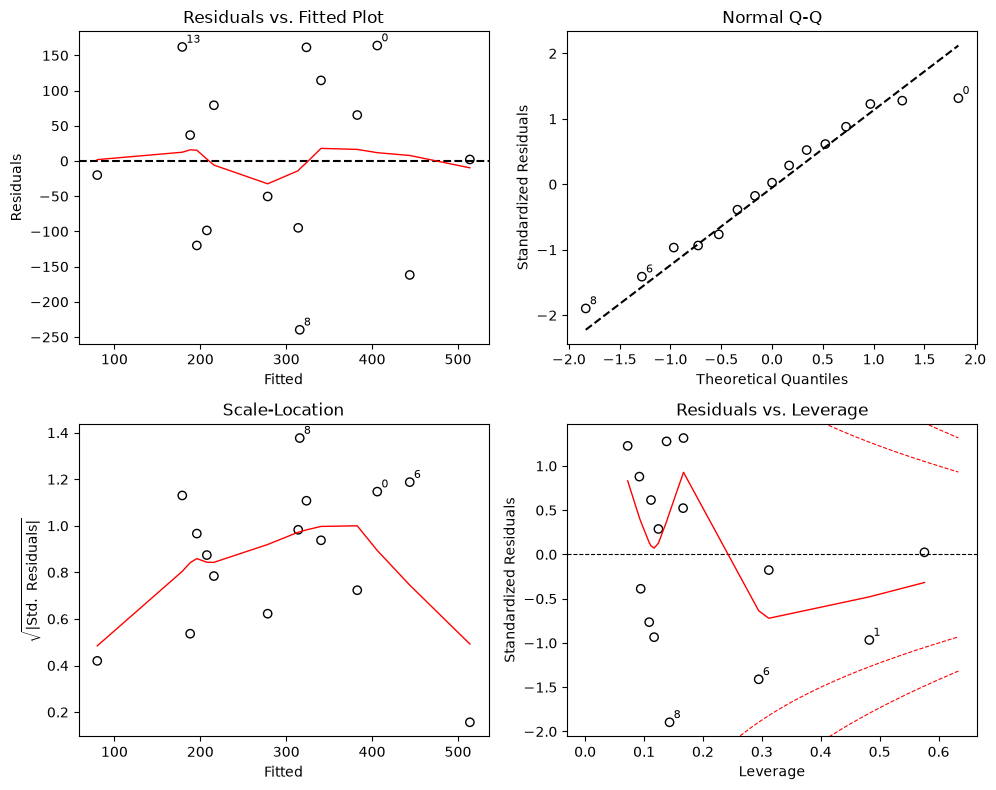

In [9]:
_ = m1_sc.plot()

In [10]:
m1_sc.X

(Intercept),time.ipc,prop.partner
f64,f64,f64
1.0,60.0,0.2
1.0,149.0,0.98
1.0,70.0,0.5
1.0,168.0,0.5
1.0,48.0,0.2
…,…,…
1.0,48.0,0.75
1.0,54.0,0.75
1.0,32.0,0.6


In [11]:
m2_sc = lm("count ~ time.ipc + I(prop.partner * time.ipc)", data=sperm)
m2_sc.summary()

Formula: count ~ time.ipc + I(prop.partner * time.ipc)

Residuals:
    Min      1Q Median     3Q    Max
-187.68 -110.54  18.12 101.95 158.20

Coefficients:
                            Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)                  140.470      64.063    0.8892   280.0506    2.193   0.04877  *
time.ipc                       5.618       1.549    2.2420     8.9936    3.626   0.00348  **
I(prop.partner * time.ipc)    -5.478       1.741   -9.2714    -1.6845   -3.146   0.00843  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 3, Residual SE = 128.023 on 12 DF
R-Squared = 0.5234, adjusted R-Squared = 0.4440
F-statistics = 6.5888 on 2 and 12 DF, p-value: 0.01

Log Likelihood = -92.3937, AIC = 192.7874, BIC = 195.6196

In [12]:
m3_sc = lm("count ~ prop.partner", data=sperm)
m3_sc.summary()

Formula: count ~ prop.partner

Residuals:
    Min      1Q Median     3Q    Max
-287.83 -111.30  18.84 117.45 210.61

Coefficients:
              Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)     451.50       86.23    265.22     637.79    5.236  0.000161  ***
prop.partner   -292.23      140.40   -595.56      11.09   -2.081  0.057727  .
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 2, Residual SE = 154.301 on 13 DF
R-Squared = 0.2500, adjusted R-Squared = 0.1923
F-statistics = 4.3322 on 1 and 13 DF, p-value: 0.06

Log Likelihood = -95.7944, AIC = 197.5889, BIC = 199.7130

In [13]:
m4_sc = lm("count ~ 1", data=sperm)
AIC(m1_sc, m3_sc, m4_sc)

,df,AIC
str,i64,f64
"""m1_sc""",4,194.7346
"""m3_sc""",3,197.588884
"""m4_sc""",2,199.903141


In [14]:
sperm2 = data("sperm.comp2", "gamair")
sperm2.head()

pair,n,count,f.age,f.height,f.weight,m.age,m.height,m.weight,m.vol
enum,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""A""",4,514,25,170,64,25,188,95,28
"""B""",27,393,24,175,58,44,180,79,20
"""C""",2,305,22,180,57,20,185,76,null
"""D""",1,485,27,183,66,30,183,67,null
"""E""",1,422,26,163,54,25,183,67,14


Formula: count ~ f.age + f.height + f.weight + m.age + m.height + m.weight + m.vol

Residuals:
    Min      1Q Median     3Q    Max
-209.03 -142.71  51.46 118.27 214.47

Coefficients:
              Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)  -1098.518    1997.984  -5823.00    3625.96  -0.5498     0.600
f.age           10.798      22.755    -43.01      64.60   0.4745     0.650
f.height        -4.639      10.910    -30.44      21.16  -0.4252     0.683
f.weight        19.716      35.709    -64.72     104.16   0.5521     0.598
m.age           -1.722      10.219    -25.89      22.44  -0.1685     0.871
m.height         6.009      10.378    -18.53      30.55   0.5791     0.581
m.weight        -4.619      12.655    -34.54      25.30  -0.3650     0.726
m.vol            5.035      17.652    -36.71      46.78   0.2853     0.784
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 8, Residual SE = 205.146 on 7 DF
R-Squared = 0.2192, adjusted 

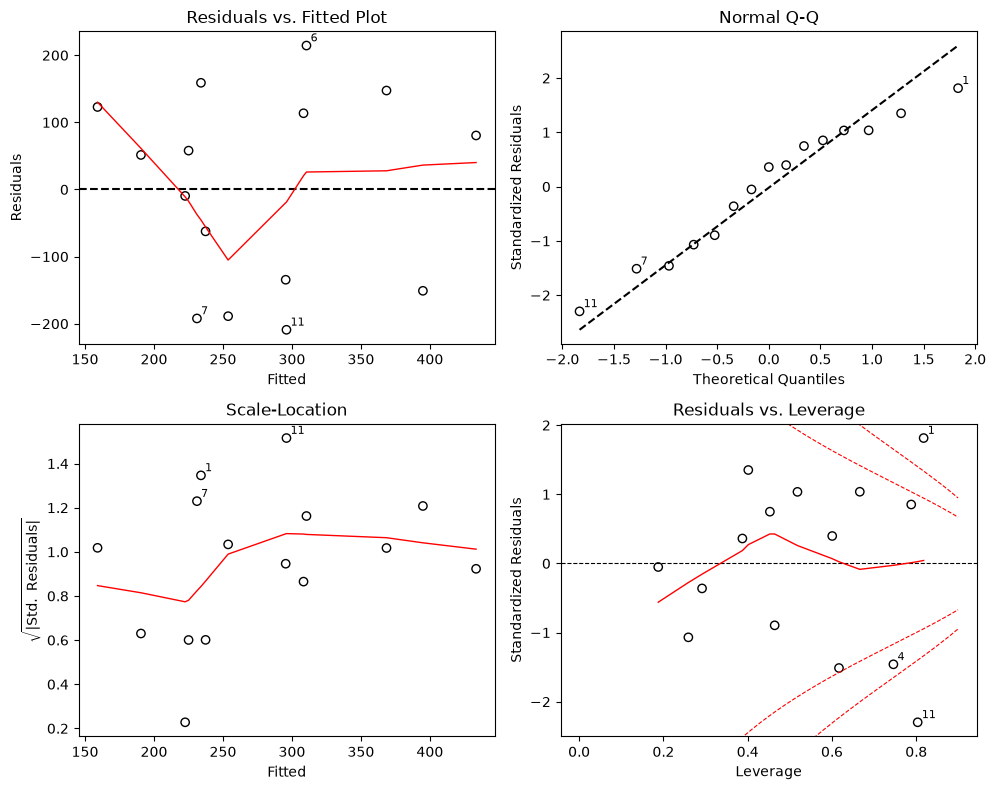

In [15]:
m1_sc2 = lm(
    "count ~ f.age + f.height + f.weight + m.age + m.height + m.weight + m.vol",
    data=sperm2,
)
m1_sc2.plot()
m1_sc2.summary()

In [16]:
m2_sc2 = lm(
    "count ~ f.age + f.height + f.weight + m.height + m.weight + m.vol", data=sperm2
)
m2_sc2.summary()

Formula: count ~ f.age + f.height + f.weight + m.height + m.weight + m.vol

Residuals:
    Min      1Q Median     3Q    Max
-201.98 -144.17  52.52 123.25 219.83

Coefficients:
              Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)  -1054.770    1856.843  -5336.66    3227.12  -0.5680     0.586
f.age            8.847      18.359    -33.49      51.18   0.4819     0.643
f.height        -5.119       9.871    -27.88      17.64  -0.5186     0.618
f.weight        20.259      33.334    -56.61      97.13   0.6078     0.560
m.height         6.033       9.727    -16.40      28.46   0.6202     0.552
m.weight        -4.473      11.834    -31.76      22.82  -0.3780     0.715
m.vol            4.506      16.281    -33.04      42.05   0.2768     0.789
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 7, Residual SE = 192.285 on 8 DF
R-Squared = 0.2160, adjusted R-Squared = -0.3720
F-statistics = 0.3674 on 6 and 8 DF, p-value: 0.88

Log Likelih

In [17]:
m3_sc2 = lm("count ~ f.weight", data=sperm2)
m3_sc2.summary()

Formula: count ~ f.weight

Residuals:
     Min       1Q Median     3Q     Max
-209.741 -119.709  7.465 92.913 273.053

Coefficients:
              Estimate  Std. Error   CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)  -1002.281     489.352  -2023.052     18.489   -2.048    0.0539  .
f.weight        22.397       8.629      4.396     40.397    2.595    0.0173  *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 22, p = 2, Residual SE = 147.286 on 20 DF
R-Squared = 0.2520, adjusted R-Squared = 0.2146
F-statistics = 6.7363 on 1 and 20 DF, p-value: 0.02

Log Likelihood = -140.0006, AIC = 286.0011, BIC = 289.2743

In [18]:
from hea.tidy import row_number

sperm3 = sperm2.filter(row_number() != 18)
m1_sc3 = lm(
    "count ~ f.age + f.height + f.weight + m.age + m.height + m.weight + m.vol", sperm3
)
m1_sc3.summary()

Formula: count ~ f.age + f.height + f.weight + m.age + m.height + m.weight + m.vol

Residuals:
     Min      1Q Median     3Q     Max
-104.779 -57.334  2.707 67.302 101.556

Coefficients:
             Estimate  Std. Error    CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)  1687.406    1251.338  -1374.5071  4749.3186   1.3485    0.2262
f.age          55.248      15.991     16.1188    94.3764   3.4549    0.0136  *
f.height       21.381       8.419      0.7796    41.9826   2.5395    0.0441  *
f.weight      -88.992      31.737   -166.6485   -11.3348  -2.8041    0.0310  *
m.age         -17.210       6.555    -33.2486    -1.1714  -2.6256    0.0393  *
m.height      -11.321       6.869    -28.1290     5.4873  -1.6481    0.1504
m.weight        6.885       7.287    -10.9450    24.7143   0.9448    0.3812
m.vol          48.996      13.938     14.8916    83.1006   3.5153    0.0126  *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 14, p = 8, Residual SE = 109.841 on 6 DF
R

### 1.6.4

In [19]:
PlantGrowth = data("PlantGrowth")
PlantGrowth.head()

weight,group
f64,enum
4.17,"""ctrl"""
5.58,"""ctrl"""
5.18,"""ctrl"""
6.11,"""ctrl"""
4.5,"""ctrl"""


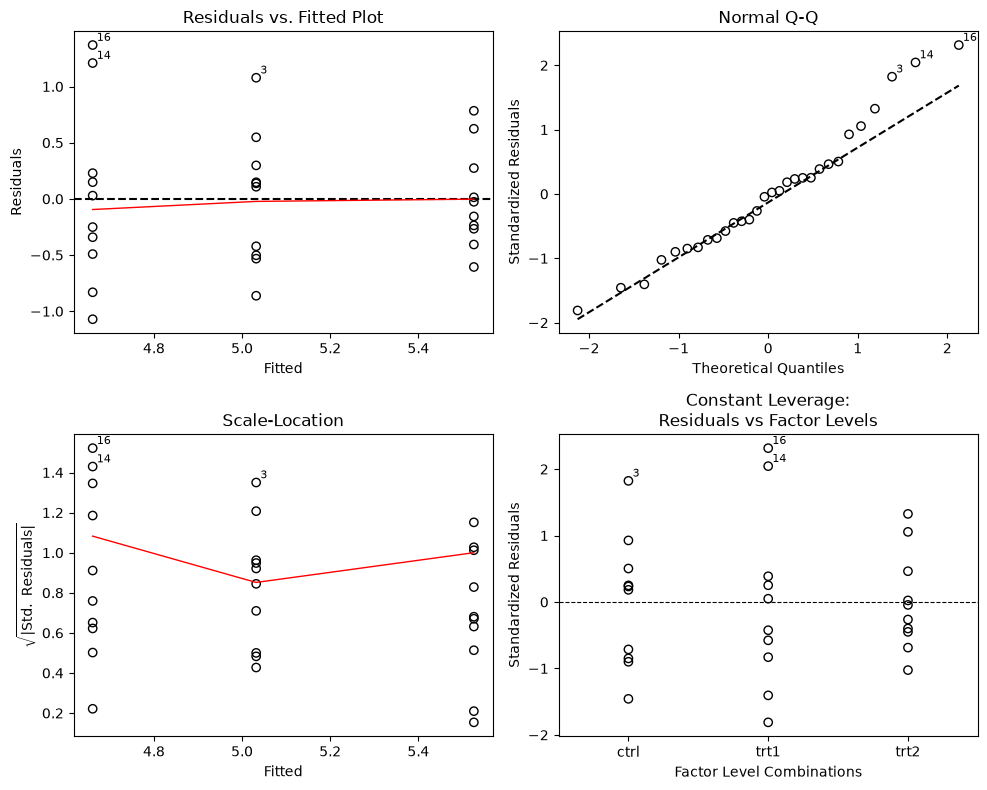

In [20]:
m1_pg = lm("weight ~ group", data=PlantGrowth)
m1_pg.summary()
_ = m1_pg.plot()

In [21]:
m0_pg = lm("weight ~ 1", data=PlantGrowth)
anova(m0_pg, m1_pg)

Analysis of Variance Table

m0_pg: weight ~ 1
m1_pg: weight ~ group

       Res.Df     RSS  Df  Sum of Sq      F   Pr(>F)
m0_pg      29  14.258
m1_pg      27  10.492   2      3.766  4.846  0.01591  *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### 2.1.1

In [22]:
stomata = data("stomata", "gamair")
stomata.head()

area,CO2,tree
f64,enum,enum
1.605574,"""1""","""1"""
1.630071,"""1""","""1"""
1.539119,"""1""","""1"""
1.718732,"""1""","""1"""
1.389616,"""1""","""2"""


In [23]:
m1_st = lm("area ~ CO2 + tree", data=stomata)
m0_st = lm("area ~ CO2", data=stomata)
anova(m0_st, m1_st)

Analysis of Variance Table

m0_st: area ~ CO2
m1_st: area ~ CO2 + tree

       Res.Df    RSS  Df  Sum of Sq      F    Pr(>F)
m0_st      22  2.135
m1_st      18  0.860   4      1.274  6.665  0.001788  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [24]:
m2_st = lm("area ~ tree", data=stomata)
anova(m2_st, m1_st)

Analysis of Variance Table

m2_st: area ~ tree
m1_st: area ~ CO2 + tree

       Res.Df   RSS  Df  Sum of Sq  F  Pr(>F)
m2_st      18  0.86
m1_st      18  0.86   0        0.0
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [25]:
st = stomata.group_by("tree", maintain_order=True).summarize(
    col("CO2").first(),
    col("area").mean(),
)
st

tree,CO2,area
enum,enum,f64
"""1""","""1""",1.623374
"""2""","""1""",1.598643
"""3""","""1""",1.162961
"""4""","""2""",2.789238
"""5""","""2""",2.903544
"""6""","""2""",2.329761


In [26]:
m3_st = lm("area ~ CO2", st)
anova(m3_st)

Analysis of Variance Table

Response: area

           Df  Sum Sq  Mean Sq  F value    Pr(>F)
CO2         1  2.2053   2.2053  27.6869  0.006247  **
Residuals   4  0.3186   0.0797
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### 2.1.3

In [27]:
Rail = data("Rail", "nlme")
Rail.head()

Rail,travel
enum,i64
"""1""",55
"""1""",53
"""1""",54
"""2""",26
"""2""",37


In [28]:
m1_rail = lm("travel ~ Rail", data=Rail)
anova(m1_rail)

Analysis of Variance Table

Response: travel

           Df  Sum Sq    Mean Sq   F value     Pr(>F)
Rail        5  9310.5  1862.1000  115.1814  1.033e-09  ***
Residuals  12   194.0    16.1667
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [29]:
rt = Rail.group_by("Rail", maintain_order=True).summarize(col("travel").mean())
rt

Rail,travel
enum,f64
"""1""",54.0
"""2""",31.666667
"""3""",84.666667
"""4""",96.0
"""5""",50.0
"""6""",82.666667


In [30]:
m0_rail = lm("travel ~ 1", data=rt)
m0_rail.summary()

Formula: travel ~ 1

Residuals:
     0      1     2     3      4     5
-12.50 -34.83 18.17 29.50 -16.50 16.17

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)     66.50       10.17     40.35      92.65    6.538   0.00125  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 6, p = 1, Residual SE = 24.914 on 5 DF
R-Squared = 0.0000, adjusted R-Squared = 0.0000
Log Likelihood = -27.2592, AIC = 58.5184, BIC = 58.1019

### 2.1.4

In [31]:
Machines = data("Machines", "nlme")
Machines

Worker,Machine,score
enum,enum,f64
"""1""","""A""",52.0
"""1""","""A""",52.8
"""1""","""A""",53.1
"""2""","""A""",51.8
"""2""","""A""",52.8
…,…,…
"""5""","""C""",72.0
"""5""","""C""",71.1
"""6""","""C""",62.0


<Axes: xlabel='Machine', ylabel='mean of score'>

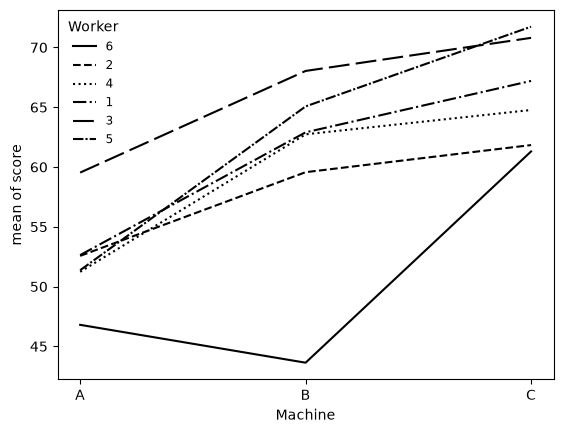

In [32]:
interaction_plot("Machine", "Worker", "score", data=Machines)

In [33]:
m1_mc = lm("score ~ Worker*Machine", data=Machines)
m0_mc = lm("score ~ Worker + Machine", data=Machines)
anova(m0_mc, m1_mc)

Analysis of Variance Table

m0_mc: score ~ Worker + Machine
m1_mc: score ~ Worker*Machine

       Res.Df      RSS  Df  Sum of Sq      F     Pr(>F)
m0_mc      46  459.817
m1_mc      36   33.287  10     426.53  46.13  1.641e-17  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [34]:
mc = (
    Machines.group_by("Worker", "Machine")
    .summarize(score=col("score").mean())
    .arrange("Worker", "Machine")
)
mc.head()

Worker,Machine,score
enum,enum,f64
"""6""","""A""",46.8
"""6""","""B""",43.633333
"""6""","""C""",61.3
"""2""","""A""",52.566667
"""2""","""B""",59.566667


In [35]:
m2_mc = lm("score ~ Worker + Machine", mc)
anova(m2_mc)

Analysis of Variance Table

Response: score

           Df    Sum Sq   Mean Sq  F value    Pr(>F)
Worker      5  413.9650   82.7930   5.8232  0.008949  **
Machine     2  585.0878  292.5439  20.5761  0.000286  ***
Residuals  10  142.1767   14.2177
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### 2.5.4

In [36]:
a1 = gmm("score ~ Machine + (1|Worker) + (1|Worker:Machine)", data=Machines)
a2 = gmm("score ~ Machine + (1|Worker) + (Machine-1|Worker)", data=Machines)
AIC(a1, a2)

,df,AIC
str,i64,f64
"""a1""",6,227.687568
"""a2""",11,230.311219


In [37]:
anova(a1, a2)

refitting model(s) with ML (instead of REML)
Analysis of Variance Table (likelihood ratio test)

a1: score ~ Machine + (1|Worker) + (1|Worker:Machine)
a2: score ~ Machine + (1|Worker) + (Machine-1|Worker)

    npar    AIC    BIC  logLik  -2*log(L)   Chisq  Df  Pr(>Chisq)
a1     6  237.3  249.2  -112.6      225.3
a2    11  238.4  260.3  -108.2      216.4  8.8516   5      0.1151
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### 2.5.5

In [38]:
b1 = gam(
    'score ~ Machine + s(Worker, bs="re") + s(Machine, Worker, bs="re")',
    data=Machines,
    method="REML",
)
b1.vcomp

name,std_dev,lower,upper
str,f64,f64,f64
"""s(Worker)""",4.78105,2.249858,10.159949
"""s(Machine,Worker)""",3.729538,2.382816,5.837403
"""scale""",0.961577,0.763254,1.211432


In [39]:
b2 = gam(
    'score ~ Machine + s(Worker,bs="re") + s(Worker,bs="re",by=Machine)',
    data=Machines,
    method="REML",
)
b2.vcomp

name,std_dev,lower,upper
str,f64,f64,f64
"""s(Worker)""",3.785904,1.7987,7.968572
"""s(Worker):MachineA""",1.940776,0.253496,14.858672
"""s(Worker):MachineB""",5.874006,2.988299,11.546349
"""s(Worker):MachineC""",2.845161,0.829838,9.754845
"""scale""",0.961576,0.763253,1.211431


In [40]:
AIC(b1, b2)

,df,AIC
str,f64,f64
"""b1""",18.859954,165.190544
"""b2""",18.985575,165.620394


### 3.3

In [41]:
heart = hea.DataFrame(
    {
        "ck": [20, 60, 100, 140, 180, 220, 260, 300, 340, 380, 420, 460],
        "ha": [2, 13, 30, 30, 21, 19, 18, 13, 19, 15, 7, 8],
        "ok": [88, 26, 8, 5, 0, 1, 1, 1, 1, 0, 0, 0],
    }
)

heart = heart.with_columns(
    n=col("ha") + col("ok"),
    p=col("ha") / (col("ha") + col("ok")),
)

heart.head()

ck,ha,ok,n,p
i64,i64,i64,i64,f64
20,2,88,90,0.022222
60,13,26,39,0.333333
100,30,8,38,0.789474
140,30,5,35,0.857143
180,21,0,21,1.0


In [42]:
from hea.family import Binomial

m0_heart = glm(
    "p ~ ck",
    data=heart,
    family=Binomial(link="logit"),
    weights=heart["n"].to_numpy(),
)

In [43]:
m0_heart.summary()

Call:
glm(formula = p ~ ck, family = binomial(link=logit))

Coefficients:
              Estimate  Std. Error  CI[2.5%]  CI[97.5]%  z value  Pr(>|z|)
(Intercept)  -2.758358    0.336696  -3.41827   -2.09845   -8.192  2.56e-16  ***
ck            0.031244    0.003619   0.02415    0.03834    8.633   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1; fixed)

    Null deviance: 271.7124  on 11 degrees of freedom
Residual deviance: 36.9286  on 10 degrees of freedom
AIC: 62.3339    BIC: 63.3037    logLik: -29.1670

Number of Fisher Scoring iterations: 6


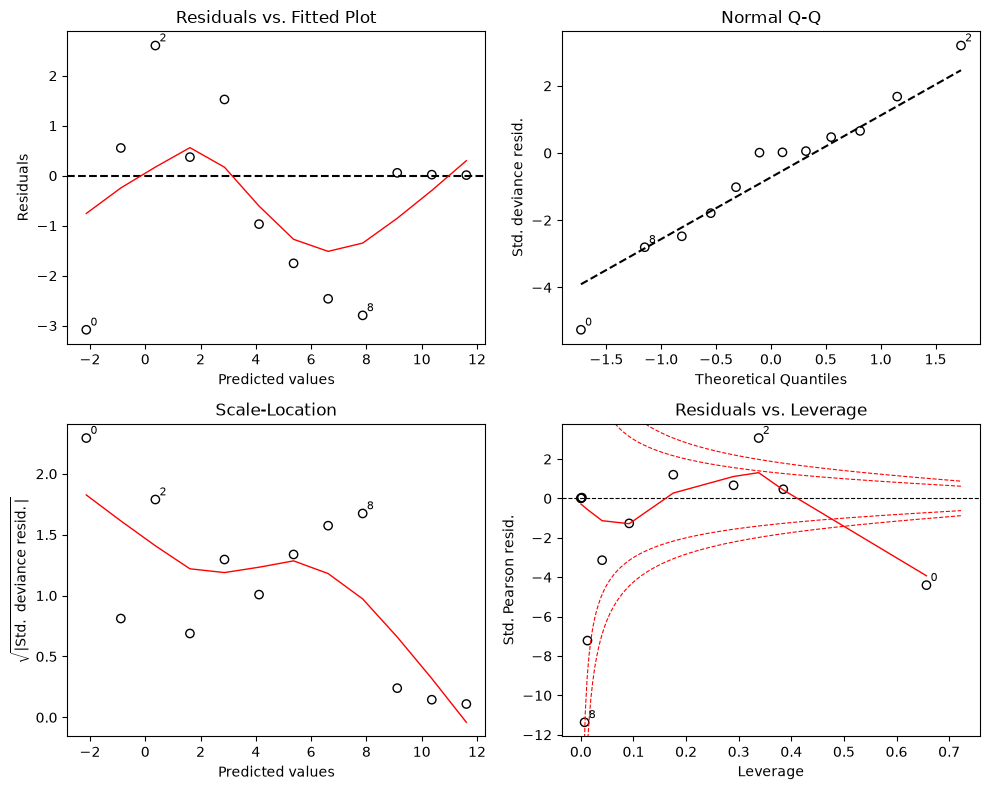

In [44]:
_ = m0_heart.plot()

In [45]:
m1_heart = glm(
    "p ~ ck + I(ck^2) + I(ck^3)",
    data=heart,
    family=Binomial(link="logit"),
    weights=heart["n"].to_numpy(),
)
m1_heart.summary()

Call:
glm(formula = p ~ ck + I(ck^2) + I(ck^3), family = binomial(link=logit))

Coefficients:
               Estimate  Std. Error    CI[2.5%]   CI[97.5]%  z value  Pr(>|z|)
(Intercept)  -5.7858843   0.9268406  -7.6024585  -3.9693100   -6.243  4.30e-10  ***
ck            0.1102205   0.0213900   0.0682968   0.1521441    5.153  2.57e-07  ***
I(ck^2)      -0.0004649   0.0001381  -0.0007355  -0.0001942   -3.367  0.000760  ***
I(ck^3)       6.448e-07   2.544e-07   1.462e-07   1.143e-06    2.535  0.011252  *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1; fixed)

    Null deviance: 271.7124  on 11 degrees of freedom
Residual deviance: 4.2525  on 8 degrees of freedom
AIC: 33.6577    BIC: 35.5974    logLik: -12.8289

Number of Fisher Scoring iterations: 6


In [46]:
anova(m0_heart, m1_heart, test="Chisq")

Analysis of Deviance Table

m0_heart: p ~ ck
m1_heart: p ~ ck + I(ck^2) + I(ck^3)

          Resid. Df  Resid. Dev  Df  Deviance   Pr(>Chi)
m0_heart         10     36.9286
m1_heart          8      4.2525   2   32.6762  8.025e-08  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


Text(0, 0.5, 'Proportion Heart Attack')

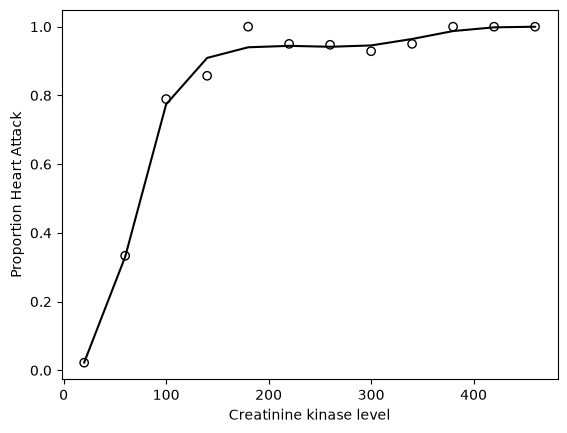

In [47]:
from hea.plot import lines, plot

ax = plot(heart["ck"], heart["p"])
lines(heart["ck"], m1_heart.fitted, ax=ax)
ax.set_xlabel("Creatinine kinase level")
ax.set_ylabel("Proportion Heart Attack")

In [48]:
pois = hea.DataFrame(
    {
        "y": [12, 14, 33, 50, 67, 74, 123, 141, 165, 204, 253, 246, 240],
        "t": np.arange(1, 14),
    }
)
pois

y,t
i64,i64
12,1
14,2
33,3
50,4
67,5
…,…
165,9
204,10
253,11


In [49]:
from hea.family import Poisson

m0_pois = glm("y ~ t", family=Poisson(), data=pois)
m0_pois.summary()

Call:
glm(formula = y ~ t, family = poisson(link=log))

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  z value  Pr(>|z|)
(Intercept)  3.140590    0.078247    2.9872     3.2940    40.14    <2e-16  ***
t            0.202121    0.007771    0.1869     0.2174    26.01    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1; fixed)

    Null deviance: 872.2058  on 12 degrees of freedom
Residual deviance: 80.6865  on 11 degrees of freedom
AIC: 166.3698    BIC: 167.4997    logLik: -81.1849

Number of Fisher Scoring iterations: 4


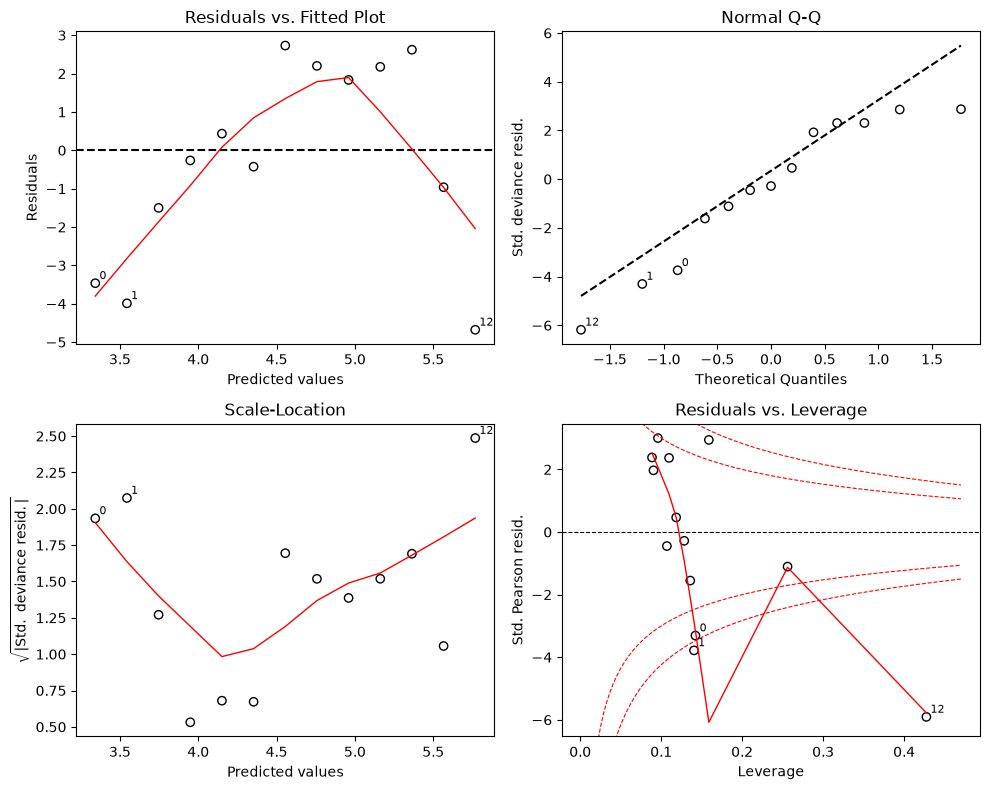

In [50]:
_ = m0_pois.plot()

In [51]:
m1_pois = glm("y ~ t + I(t^2)", family=Poisson(), data=pois)
m1_pois.summary()

Call:
glm(formula = y ~ t + I(t^2), family = poisson(link=log))

Coefficients:
              Estimate  Std. Error  CI[2.5%]  CI[97.5]%  z value  Pr(>|z|)
(Intercept)   1.901459    0.186877   1.53519    2.26773   10.175   < 2e-16  ***
t             0.556003    0.045780   0.46628    0.64573   12.145   < 2e-16  ***
I(t^2)       -0.021346    0.002659  -0.02656   -0.01614   -8.029  9.82e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1; fixed)

    Null deviance: 872.2058  on 12 degrees of freedom
Residual deviance: 9.2402  on 10 degrees of freedom
AIC: 96.9236    BIC: 98.6184    logLik: -45.4618

Number of Fisher Scoring iterations: 4


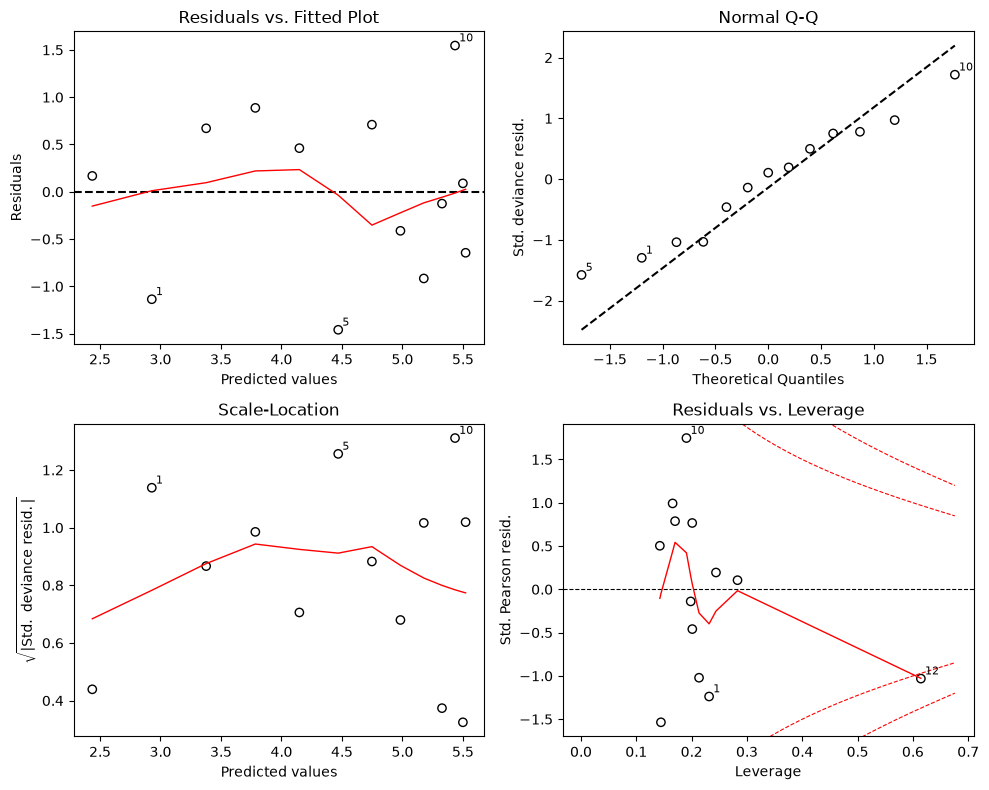

In [52]:
_ = m1_pois.plot()

In [53]:
anova(m0_pois, m1_pois, test="Chisq")

Analysis of Deviance Table

m0_pois: y ~ t
m1_pois: y ~ t + I(t^2)

         Resid. Df  Resid. Dev  Df  Deviance   Pr(>Chi)
m0_pois         11     80.6865
m1_pois         10      9.2402   1   71.4462  2.849e-17  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### 3.5.2

In [54]:
sole = data("sole", "gamair")
sole.head()

rowname,la,lo,t,eggs,stage,a.0,a.1
i64,f64,f64,f64,f64,i64,f64,f64
1,50.055,-5.87,49.5,0.0,1,0.0,2.4
2,50.09,-6.146,49.5,0.0,1,0.0,2.4
3,50.123,-6.39,49.5,0.0,1,0.0,2.4
4,50.178,-6.15,49.5,0.0,1,0.0,2.4
5,50.188,-5.902,49.5,0.0,1,0.0,2.4


In [55]:
sole = sole.mutate(off=(col("a.1") - col("a.0")).log(), a=(col("a.1") + col("a.0")) / 2)
solr = sole.mutate(
    t=(col("t") - col("t").mean()) / col("t").std(),
    la=col("la") - col("la").mean(),
    lo=col("lo") - col("lo").mean(),
)

In [56]:
from hea.family import Quasi

formula = """
    eggs ~ offset(off) + lo + la + t
    + I(lo*la) + I(lo^2) + I(la^2) + I(t^2)
    + I(lo*t) + I(la*t) + I(lo^3) + I(la^3) + I(t^3)
    + I(lo*la*t) + I(lo^2*la) + I(lo*la^2)
    + I(lo^2*t) + I(la^2*t) + I(la*t^2) + I(lo*t^2)
    + a + I(a*t) + I(t^2*a)
"""
b0 = glm(formula, family=Quasi(link="log", variance="mu"), data=solr)
b0.summary()

Call:
glm(formula = 
    eggs ~ offset(off) + lo + la + t
    + I(lo*la) + I(lo^2) + I(la^2) + I(t^2)
    + I(lo*t) + I(la*t) + I(lo^3) + I(la^3) + I(t^3)
    + I(lo*la*t) + I(lo^2*la) + I(lo*la^2)
    + I(lo^2*t) + I(la^2*t) + I(la*t^2) + I(lo*t^2)
    + a + I(a*t) + I(t^2*a)
, family = quasi(link=log, variance='mu'))

Coefficients:
                 Estimate  Std. Error    CI[2.5%]   CI[97.5]%   t value  Pr(>|t|)
(Intercept)      -0.03836     0.14561   -0.323749    0.247020   -0.2635  0.792215
lo                5.22548     0.39438    4.452505    5.998460   13.2498   < 2e-16  ***
la               -5.94345     0.50139   -6.926148   -4.960743  -11.8540   < 2e-16  ***
t                -2.43222     0.25762   -2.937148   -1.927284   -9.4410   < 2e-16  ***
I(lo * la)        3.38576     0.61801    2.174484    4.597046    5.4785  5.00e-08  ***
I(lo^2)          -3.98406     0.36747   -4.704288   -3.263828  -10.8418   < 2e-16  ***
I(la^2)          -4.21517     0.56232   -5.317294   -3.113051   -

In [57]:
b1 = gam(formula, family=Quasi(link="log", variance="mu"), data=solr, method="REML")
b1.summary()


Family: quasi
Link function: log

Formula: 
    eggs ~ offset(off) + lo + la + t
    + I(lo*la) + I(lo^2) + I(la^2) + I(t^2)
    + I(lo*t) + I(la*t) + I(lo^3) + I(la^3) + I(t^3)
    + I(lo*la*t) + I(lo^2*la) + I(lo*la^2)
    + I(lo^2*t) + I(la^2*t) + I(la*t^2) + I(lo*t^2)
    + a + I(a*t) + I(t^2*a)


Parametric coefficients:
                 Estimate  Std. Error   t value  Pr(>|t|)
(Intercept)      -0.03836     0.11543   -0.3324  0.739664
lo                5.22548     0.31265   16.7135   < 2e-16  ***
la               -5.94345     0.39748  -14.9529   < 2e-16  ***
t                -2.43222     0.20424  -11.9086   < 2e-16  ***
I(lo * la)        3.38576     0.48995    6.9104  7.03e-12  ***
I(lo^2)          -3.98406     0.29134  -13.6748   < 2e-16  ***
I(la^2)          -4.21517     0.44579   -9.4555   < 2e-16  ***
I(t^2)           -1.77607     0.20838   -8.5232   < 2e-16  ***
I(lo * t)         0.20029     0.27847    0.7193  0.472090
I(la * t)         1.82637     0.37530    4.8664  1.25e-0

### 4.6

In [58]:
trees = data("trees", "mgcv")

In [59]:
from hea.family import Gamma

ct1 = gam("Volume ~ s(Height) + s(Girth)", family=Gamma(link="log"), data=trees)
ct1.summary()


Family: Gamma
Link function: log

Formula: Volume ~ s(Height) + s(Girth)

Parametric coefficients:
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)   3.27570     0.01492    219.6    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
             edf  Ref.df       F   p-value
s(Height)  1.000   1.000   31.32  7.07e-06  ***
s(Girth)   2.422   3.044  219.28   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.973  Deviance explained = 97.8%
GCV = 0.0080824  Scale est. = 0.006899  n = 31


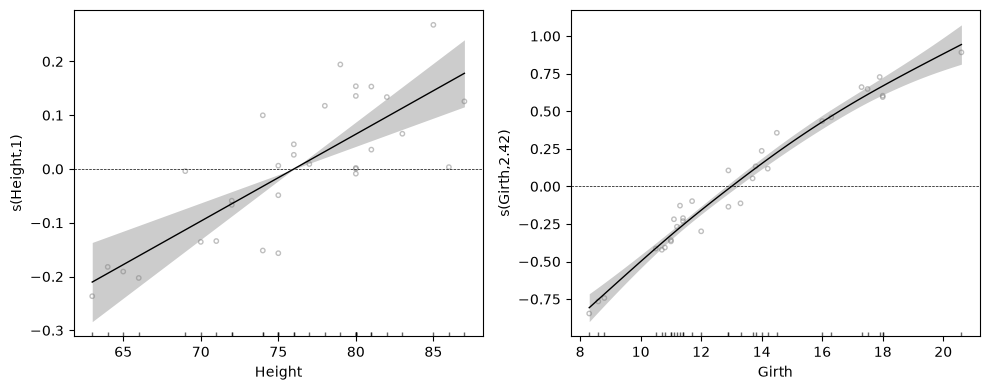

In [60]:
ax = ct1.plot_smooth(partial_residuals=True)

In [61]:
ct2 = gam(
    'Volume ~ s(Height, bs="cr") + s(Girth, bs="cr")',
    family=Gamma(link="log"),
    data=trees,
)
ct2.summary()


Family: Gamma
Link function: log

Formula: Volume ~ s(Height, bs="cr") + s(Girth, bs="cr")

Parametric coefficients:
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)   3.27570     0.01492    219.6    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
             edf  Ref.df       F   p-value
s(Height)  1.000   1.000   31.32  7.07e-06  ***
s(Girth)   2.419   3.035  219.51   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.973  Deviance explained = 97.8%
GCV = 0.0080805  Scale est. = 0.006898  n = 31


In [62]:
ct3 = gam(
    'Volume ~ s(Height) + s(Girth, bs="cr", k=20)', family=Gamma(link="log"), data=trees
)
ct3.summary()


Family: Gamma
Link function: log

Formula: Volume ~ s(Height) + s(Girth, bs="cr", k=20)

Parametric coefficients:
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)   3.27570     0.01492    219.6    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
             edf  Ref.df       F   p-value
s(Height)  1.000   1.000   31.31  7.08e-06  ***
s(Girth)   2.424   3.049  218.92   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.973  Deviance explained = 97.8%
GCV = 0.008083  Scale est. = 0.006899  n = 31


In [63]:
ct4 = gam(
    "Volume ~ s(Height) + s(Girth)",
    family=Gamma(link="log"),
    gamma=1.4,
    data=trees,
)
ct4.summary()


Family: Gamma
Link function: log

Formula: Volume ~ s(Height) + s(Girth)

Parametric coefficients:
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)   3.27577     0.01504    217.8    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
             edf  Ref.df       F   p-value
s(Height)  1.000   1.000   31.51  6.80e-06  ***
s(Girth)   2.170   2.735  237.10   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.972  Deviance explained = 97.7%
GCV = 0.009228  Scale est. = 0.0070127  n = 31


In [64]:
ct5 = gam("Volume ~ s(Height, Girth, k=25)", family=Gamma(link="log"), data=trees)
ct5.summary()


Family: Gamma
Link function: log

Formula: Volume ~ s(Height, Girth, k=25)

Parametric coefficients:
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)   3.27583     0.01579    207.4    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                   edf  Ref.df      F  p-value
s(Height,Girth)  4.791   6.487  161.5   <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.966  Deviance explained = 97.7%
GCV = 0.0093576  Scale est. = 0.0077321  n = 31


In [65]:
ct6 = gam("Volume ~ te(Height, Girth, k=5)", family=Gamma(link="log"), data=trees)
ct6.summary()


Family: Gamma
Link function: log

Formula: Volume ~ te(Height, Girth, k=5)

Parametric coefficients:
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)   3.27584     0.01522    215.2    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                    edf  Ref.df      F  p-value
te(Height,Girth)  3.000   3.000  377.2   <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.973  Deviance explained = 97.7%
GCV = 0.0081971  Scale est. = 0.0071821  n = 31


/Users/ziweih/Works/hea/hea/models/gam.py:9044: UserWarning: PIRLS algorithm did not converge
  self._estimate_and_assemble(sp, method)


<Axes: label='ct6', title={'center': 'te(Height,Girth,3)'}, xlabel='Height', ylabel='Girth'>

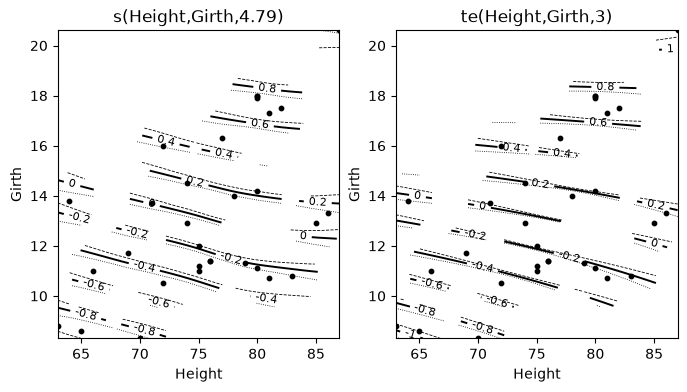

In [66]:
fig, ax = plt.subplot_mosaic(mosaic=[["ct5", "ct6"]], figsize=(8, 4))

ct5.plot_smooth(ax=ax["ct5"])
ct6.plot_smooth(ax=ax["ct6"])

In [67]:
from hea.dtypes import Enum, Int64

trees = data("trees", "mgcv")
trees = trees.mutate(
    Hclass=((col("Height") / 10).floor() - 5)
    .cast(Int64)
    .replace_strict(
        [1, 2, 3],
        ["small", "medium", "large"],
        return_dtype=Enum(["small", "medium", "large"]),
    ),
)
trees

,Girth,Height,Volume,Hclass
i64,f64,i64,f64,enum
1,8.3,70,10.3,"""medium"""
2,8.6,65,10.3,"""small"""
3,8.8,63,10.2,"""small"""
4,10.5,72,16.4,"""medium"""
5,10.7,81,18.8,"""large"""
…,…,…,…,…
27,17.5,82,55.7,"""large"""
28,17.9,80,58.3,"""large"""
29,18.0,80,51.5,"""large"""


In [68]:
ct7 = gam("Volume ~ Hclass + s(Girth)", family=Gamma(link="log"), data=trees)

ct7.summary()


Family: Gamma
Link function: log

Formula: Volume ~ Hclass + s(Girth)

Parametric coefficients:
              Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)    3.12722     0.04899   63.836   < 2e-16  ***
Hclassmedium   0.13415     0.05534    2.424   0.02275  *
Hclasslarge    0.23000     0.06253    3.678   0.00110  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
            edf  Ref.df      F  p-value
s(Girth)  2.444   3.076  152.7   <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.967  Deviance explained = 96.9%
GCV = 0.012075  Scale est. = 0.010192  n = 31


In [69]:
anova(ct7)


Family: Gamma
Link function: log

Formula: Volume ~ Hclass + s(Girth)

Parametric Terms:
        df      F  p-value
Hclass   2  6.802  0.00428  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
            edf  Ref.df      F  p-value
s(Girth)  2.444   3.076  152.7   <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


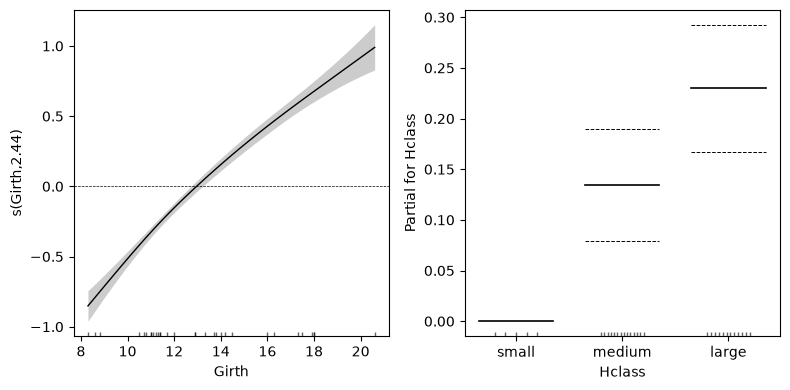

In [70]:
_ = ct7.plot_smooth(all_terms=True, figsize=(8, 4))

### 7.2

In [71]:
brain = data("brain", "gamair")
brain = brain.filter(col("medFPQ") > 5e-3)

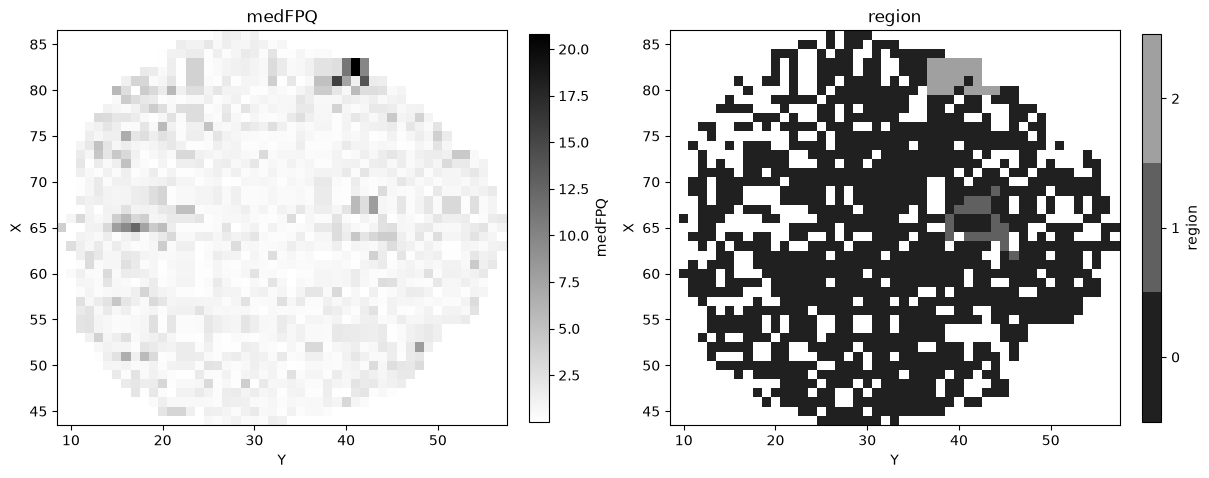

In [72]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X_min, X_max = brain["X"].min(), brain["X"].max()
Y_min, Y_max = brain["Y"].min(), brain["Y"].max()
nx = X_max - X_min + 1
ny = Y_max - Y_min + 1

medFPQ = np.full((nx, ny), np.nan)  # rows=X, cols=Y
region = np.full((nx, ny), np.nan)
for row in brain.iter_rows(named=True):
    i = row["X"] - X_min  # row index = X
    j = row["Y"] - Y_min  # col index = Y
    medFPQ[i, j] = row["medFPQ"]
    if row["region"] is not None:
        region[i, j] = row["region"]

extent = (
    Y_min - 0.5,
    Y_max + 0.5,
    X_min - 0.5,
    X_max + 0.5,
)  # (left, right, bottom, top)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im0 = axes[0].imshow(
    medFPQ, origin="lower", cmap="gray_r", aspect="equal", extent=extent
)
fig.colorbar(im0, ax=axes[0], label="medFPQ", shrink=0.8)
axes[0].set(xlabel="Y", ylabel="X", title="medFPQ")

cmap_reg = ListedColormap(["#202020", "#606060", "#A0A0A0"])
im1 = axes[1].imshow(
    region,
    origin="lower",
    cmap=cmap_reg,
    aspect="equal",
    vmin=-0.5,
    vmax=2.5,
    extent=extent,
)
fig.colorbar(im1, ax=axes[1], ticks=[0, 1, 2], label="region", shrink=0.8)
axes[1].set(xlabel="Y", ylabel="X", title="region")
plt.show()

In [73]:
m0 = gam("medFPQ ~ s(Y, X, k=100)", data=brain)
m1 = gam("medFPQ^.25 ~ s(Y, X, k=100)", data=brain)
m2 = gam("medFPQ ~ s(Y, X, k=100)", data=brain, family=Gamma(link="log"))
m3 = gam("medFPQ ~ s(Y,k=30) + s(X,k=30)", data=brain, family=Gamma(link="log"))

tm = gam("medFPQ ~ te(Y, X, k=10)", data=brain, family=Gamma(link="log"))

# (d) main effects + interaction, estimated separately
tm1 = gam(
    'medFPQ ~ s(Y, k=10, bs="cr") + s(X, k=10, bs="cr") + ti(Y, X, k=10)',
    data=brain,
    family=Gamma(link="log"),
)

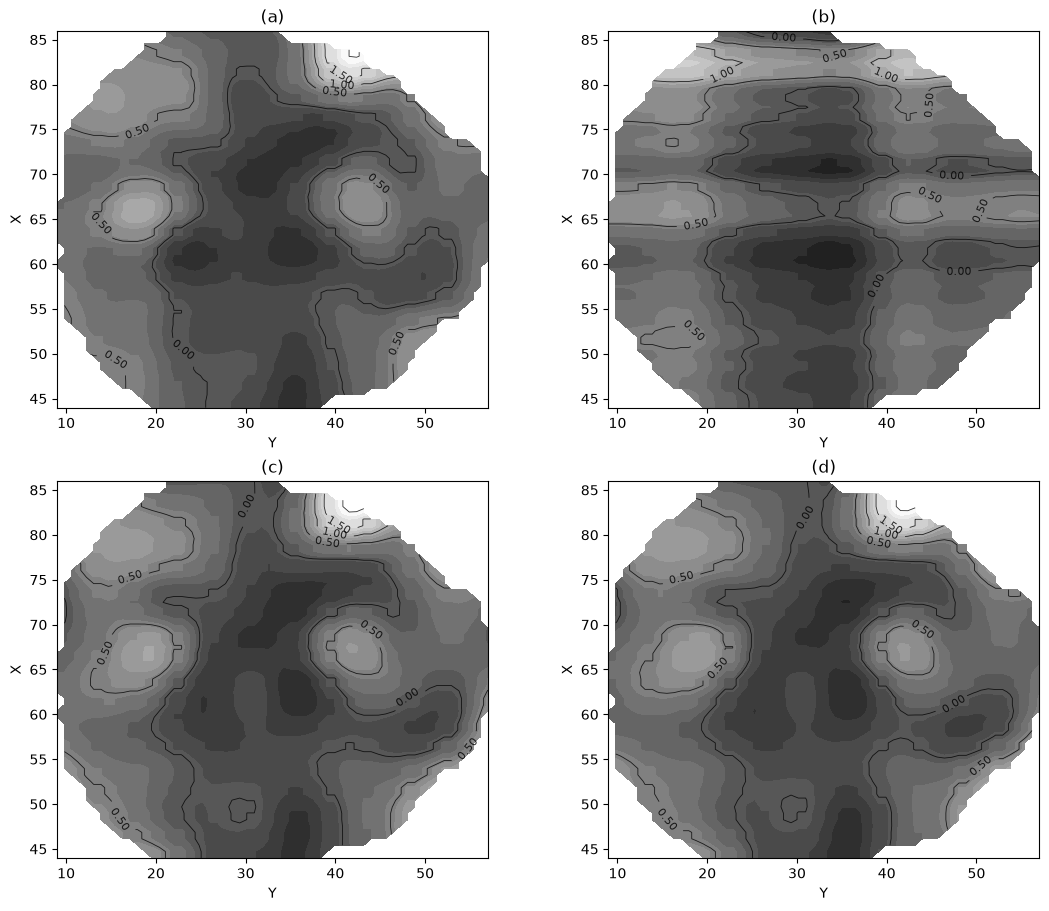

In [74]:
fig, axes = plt.subplot_mosaic(
    [["a", "b"], ["c", "d"]],
    figsize=(11, 9),
    constrained_layout=True,
)
for label, m in zip("abcd", [m2, m3, tm, tm1]):
    m.vis(view=("Y", "X"), too_far=0.03, n_grid=60).plot(
        kind="contour",
        ax=axes[label],
        cmap="gray",
        levels=np.linspace(-1, 2, 20),
        contour_levels=np.linspace(0, 2, 5),
        colorbar=False,
        clabel=True,
    )
    axes[label].set_title(f"({label})")
plt.show()

### 7.3

In [75]:
wesdr = data("wesdr", "gamair")
wesdr

dur,gly,bmi,ret
f64,f64,f64,i64
10.3,13.7,23.8,0
9.9,13.5,23.5,0
15.6,13.8,24.8,0
26.0,13.0,21.6,1
13.8,11.1,24.6,1
…,…,…,…
5.9,18.7,21.7,1
6.8,14.6,15.2,0
5.8,11.9,32.8,1


In [76]:
b = gam(
    "ret ~ s(dur,k=5) + s(gly,k=5) + s(bmi,k=5) "
    "+ ti(dur,gly,k=5) + ti(dur,bmi,k=5) + ti(gly,bmi,k=5)",
    select=True,
    data=wesdr,
    family=Binomial(),
    method="ML",
)
b.summary()


Family: binomial
Link function: logit

Formula: ret ~ s(dur,k=5) + s(gly,k=5) + s(bmi,k=5) + ti(dur,gly,k=5) + ti(dur,bmi,k=5) + ti(gly,bmi,k=5)

Parametric coefficients:
             Estimate  Std. Error  z value  Pr(>|z|)
(Intercept)  -0.40266     0.08978   -4.485  7.29e-06  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                   edf  Ref.df      Chi.sq   p-value
s(dur)       2.9709187   4.000  15.7440531  0.000647  ***
s(gly)       0.9891813   4.000  87.9393010   < 2e-16  ***
s(bmi)       1.9681488   4.000  11.2417805  0.001552  **
ti(dur,gly)  0.0003136  16.000   0.0001827  0.597365
ti(dur,bmi)  0.0001717  16.000   5.645e-05  0.800040
ti(gly,bmi)  1.5478286  16.000   7.9835335  0.004207  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.22  Deviance explained = 18.3%
-ML = 385.53  Scale est. = 1  n = 669


/Users/ziweih/Works/hea/hea/models/gam.py:12526: RuntimeWarning: overflow encountered in exp
  upper = np.exp(log_sd + z * se)


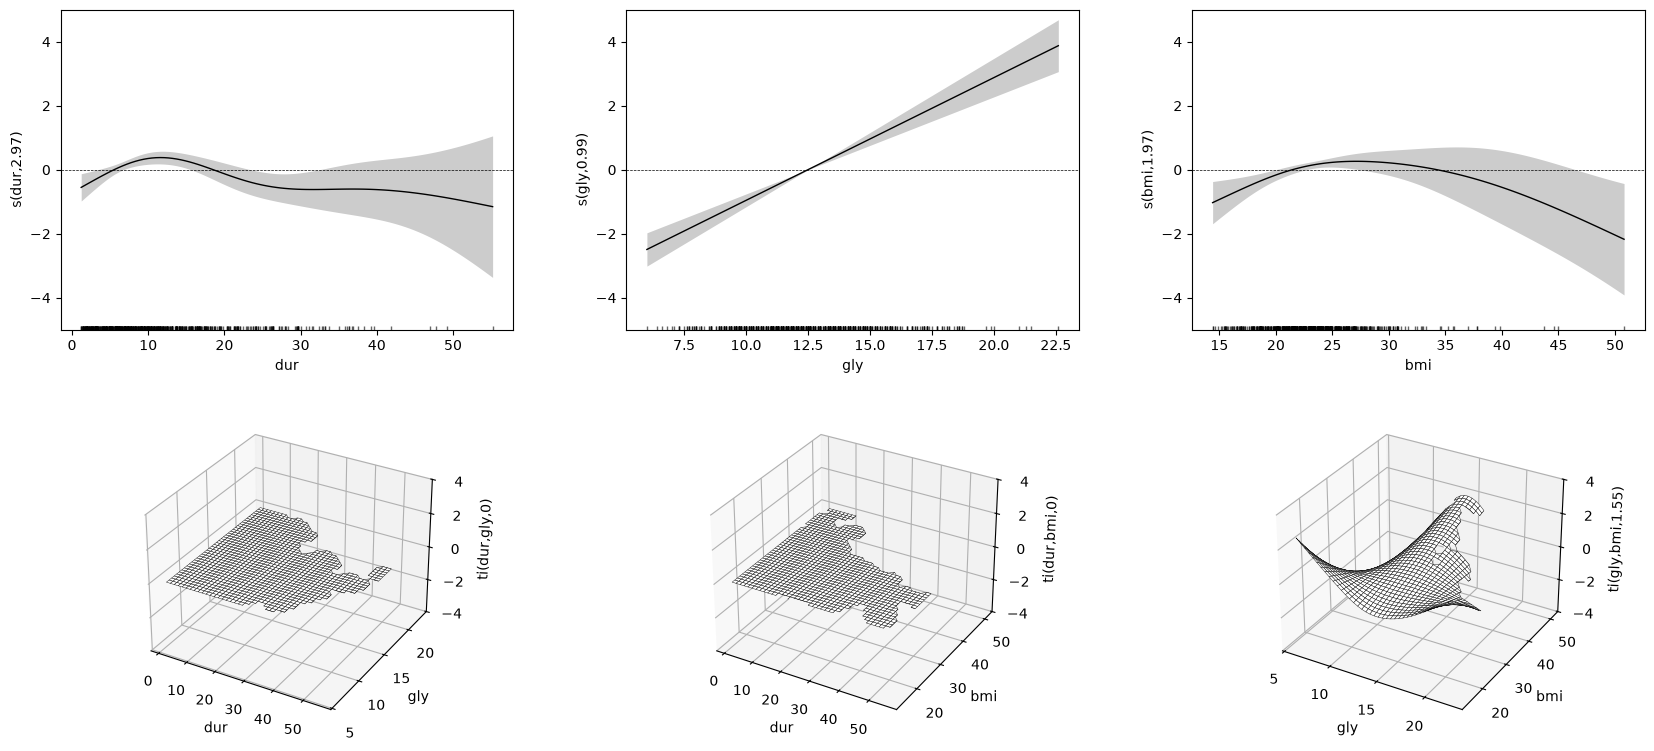

In [77]:
fig7_9 = b.plot_smooth(
    select=["s(dur)", "s(gly)", "s(bmi)", "ti(dur,gly)", "ti(dur,bmi)", "ti(gly,bmi)"],
    scheme=[0, 0, 0, 1, 1, 1],
    n_cols=3,
)

for i in range(3):
    fig7_9.axes[i].set_ylim(-5, 5)
for i in range(3, 6):
    fig7_9.axes[i].set_zlim(-4, 4)

### 7.4

In [78]:
chicago = data("chicago", "gamair")
ap1 = gam(
    'death ~ s(time,bs="cr",k=200)+s(pm10median,bs="cr")+s(so2median,bs="cr")+s(o3median,bs="cr")+s(tmpd,bs="cr")',
    data=chicago,
    family=Poisson(),
)

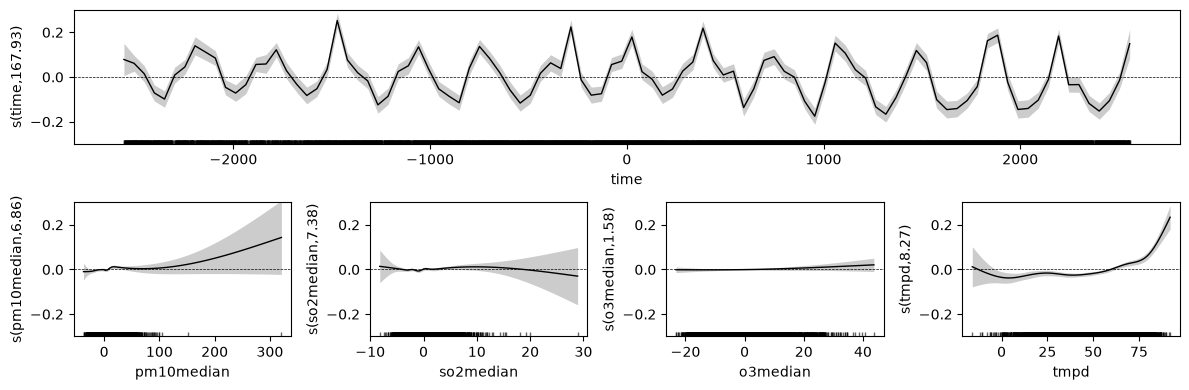

In [79]:
mosaic = """
AAAA
BCDE
"""
fig, ax = plt.subplot_mosaic(mosaic, figsize=(12, 4))


ap1.plot_smooth(select="s(time)", ax=ax["A"], ylim=(-0.3, 0.3))

smooths = ["s(pm10median)", "s(so2median)", "s(o3median)", "s(tmpd)"]
for s, lab in zip(smooths, ["B", "C", "D", "E"]):
    ap1.plot_smooth(select=s, ax=ax[lab], ylim=(-0.3, 0.3))

fig.tight_layout()

In [80]:
from hea.family import tw

mack = data("mack", package="gamair")
mack = mack.drop_nulls(
    subset=[
        "egg.count",
        "lon",
        "lat",
        "b.depth",
        "c.dist",
        "salinity",
        "temp.surf",
        "temp.20m",
        "net.area",
    ]
)
mack = mack.with_columns(
    log_net_area=col("net.area").log(),
    b_depth_sqrt=col("b.depth").sqrt(),
)

gmtw = gam(
    "egg.count ~ s(lon, lat, k=100) + s(I(b.depth^0.5)) + s(c.dist) + s(salinity) + s(temp.surf) + s(temp.20m) + offset(log_net_area)",
    mack,
    family=tw(),
    method="REML",
    select=True,
)

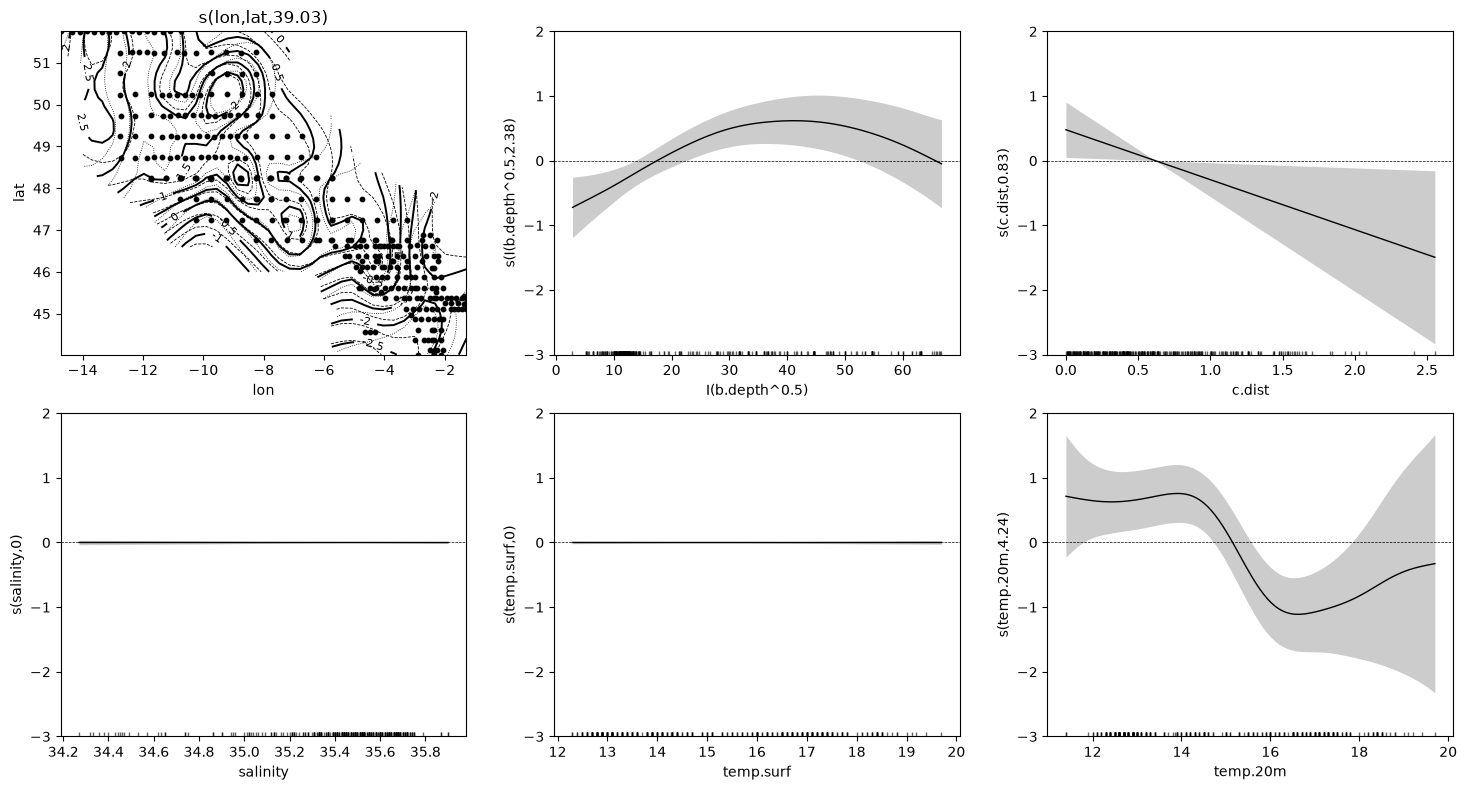

In [81]:
fig = gmtw.plot_smooth(n_cols=3)
for i in range(1, 6):
    fig.axes[i].set_ylim(-3, 2)

### 7.8

In [82]:
import hea
from hea.family import cox_ph

pbc = (
    data("pbc")
    .drop_nulls(
        subset=[
            "time",
            "status",
            "trt",
            "sex",
            "protime",
            "platelet",
            "age",
            "bili",
            "albumin",
        ]
    )
    .mutate(status1=(col("status") == 2).cast(hea.dtypes.Float64))
)
m = gam(
    "time ~ trt + sex + s(sqrt(protime)) + s(platelet) + s(age) + s(bili) + s(albumin)",
    pbc,
    family=cox_ph(),
    weights=pbc.pull("status1"),
    method="REML",
)


Family: Cox PH
Link function: identity

Formula: time ~ trt + sex + s(sqrt(protime)) + s(platelet) + s(age) + s(bili) + s(albumin)

Parametric coefficients:
      Estimate  Std. Error  z value  Pr(>|z|)
trt    0.06715     0.19407   0.3460    0.7293
sexf  -0.49511     0.26700  -1.8543    0.0637  .
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                    edf  Ref.df  Chi.sq   p-value
s(sqrt(protime))  1.003   1.007  13.324  0.000267  ***
s(platelet)       1.000   1.000   5.791  0.016111  *
s(age)            6.043   7.172  29.415  0.000140  ***
s(bili)           4.264   5.223  89.519   < 2e-16  ***
s(albumin)        1.000   1.000  31.084   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Deviance explained = 30.4%
-REML = 547.26  Scale est. = 1  n = 308


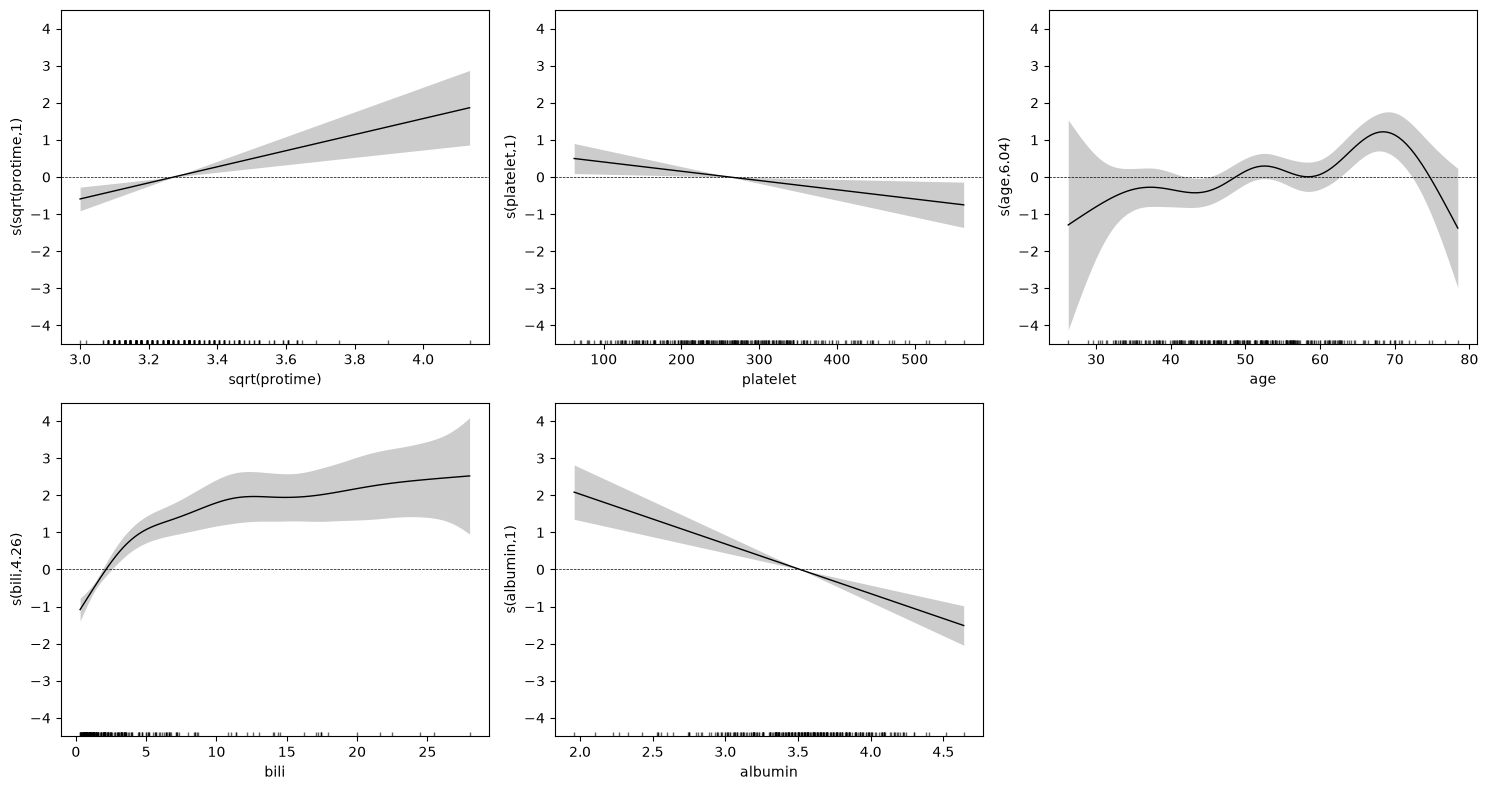

In [83]:
m.summary()
_ = m.plot_smooth(n_cols=3, ylim=(-4.5, 4.5))

In [84]:
from hea import session_info

session_info()

Python version 3.13.11 (CPython)
Platform: arm64-darwin25.4.0
Running under: macOS 26.4.1

BLAS:   accelerate
LAPACK: accelerate

locale: C.UTF-8

time zone: CEST

hea version 0.1.9

attached packages:
[1] IPython_9.14.1    hea_0.1.9         matplotlib_3.11.0 numpy_2.5.0
[5] pandas_3.0.3      polars_1.41.2     pyarrow_24.0.0    pytest_9.1.1
[9] scipy_1.18.0

loaded via a namespace (and not attached):
 [1] Cython_3.2.9             PIL_12.2.0               appnope_0.1.4
 [4] argparse_1.1             asttokens_3.0.1          charset_normalizer_3.4.7
 [7] comm_0.2.3               contourpy_1.3.3          csv_1.0
[10] ctypes_1.1.0             cycler_0.12.1            cython_3.2.9
[13] dateutil_2.9.0.post0     debugpy_1.8.21           decimal_1.70
[16] decorator_5.3.1          defusedxml_0.7.1         executing_2.2.1
[19] fontTools_4.63.0         ipaddress_1.0            ipykernel_7.3.0
[22] jedi_0.20.0              json_2.0.9               jupyter_client_8.9.1
[25] jupyter_core_5.9.1       